<a href="https://colab.research.google.com/github/pranjal-coders/PRANJAL_PAL/blob/main/EDA_Course_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
# NAME : PRANJAL PAL
# REG. NO. : 23BDS0148
# EDA COURSE PROJECT - PHASE 1
# Dataset: PhD Publications Data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [12]:
# TASK 1: LOADING THE DATASET
print("=== TASK 1: LOADING DATASET ===")
url = "https://raw.githubusercontent.com/salemprakash/EDA/main/Data/PhDPublications.csv"
df = pd.read_csv(url)

# Clean up index column if present from R CSV output
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

print(f"Dataset successfully loaded. Shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())

=== TASK 1: LOADING DATASET ===
Dataset successfully loaded. Shape: (915, 7)

First 5 rows:
   rownames  articles  gender married  kids  prestige  mentor
0         1         0    male     yes     0      2.52       7
1         2         0  female      no     0      2.05       6
2         3         0  female      no     0      3.75       6
3         4         0    male     yes     1      1.18       3
4         5         0  female      no     0      3.75      26


In [13]:
# TASK 2: BASIC STATISTICAL ANALYSIS
print("\n=== TASK 2: BASIC STATISTICAL ANALYSIS ===")

print("\n--- Dataframe Info ---")
df.info()

print("\n--- Summary Statistics (Numerical & Categorical) ---")
print(df.describe(include="all"))

print("\n--- Skewness of Numerical Features ---")
numeric_cols = df.select_dtypes(include=[np.number]).columns
print(df[numeric_cols].skew())


=== TASK 2: BASIC STATISTICAL ANALYSIS ===

--- Dataframe Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 915 entries, 0 to 914
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   rownames  915 non-null    int64  
 1   articles  915 non-null    int64  
 2   gender    915 non-null    object 
 3   married   915 non-null    object 
 4   kids      915 non-null    int64  
 5   prestige  915 non-null    float64
 6   mentor    915 non-null    int64  
dtypes: float64(1), int64(4), object(2)
memory usage: 50.2+ KB

--- Summary Statistics (Numerical & Categorical) ---
          rownames    articles gender married        kids    prestige  \
count   915.000000  915.000000    915     915  915.000000  915.000000   
unique         NaN         NaN      2       2         NaN         NaN   
top            NaN         NaN   male     yes         NaN         NaN   
freq           NaN         NaN    494     606         NaN         Na

In [14]:
# TASK 3: HANDLING MISSING DATA
print("\n=== TASK 3: HANDLING MISSING DATA ===")
missing_count = df.isnull().sum()
missing_pct = (missing_count / len(df)) * 100

missing_df = pd.DataFrame({"Missing Values": missing_count, "Percentage (%)": missing_pct})
print(missing_df)

# Imputation logic if missing values exist
if missing_count.sum() > 0:
    for col in numeric_cols:
        if df[col].isnull().sum() > 0:
            df[col].fillna(df[col].median(), inplace=True)
    for col in df.select_dtypes(include=['object', 'category']).columns:
        if df[col].isnull().sum() > 0:
            df[col].fillna(df[col].mode()[0], inplace=True)
    print("Missing values handled using median/mode imputation.")
else:
    print("No missing values detected in the dataset.")


=== TASK 3: HANDLING MISSING DATA ===
          Missing Values  Percentage (%)
rownames               0             0.0
articles               0             0.0
gender                 0             0.0
married                0             0.0
kids                   0             0.0
prestige               0             0.0
mentor                 0             0.0
No missing values detected in the dataset.


In [15]:
# TASK 4: DATA CLEANING
print("\n=== TASK 4: DATA CLEANING ===")

# Check duplicates
duplicate_rows = df.duplicated().sum()
print(f"Duplicate rows found: {duplicate_rows}")
if duplicate_rows > 0:
    df = df.drop_duplicates()
    print("Duplicate rows removed.")

# Strip whitespace from categorical strings
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = df[col].str.strip()

print("Data types after cleaning:")
print(df.dtypes)


=== TASK 4: DATA CLEANING ===
Duplicate rows found: 0
Data types after cleaning:
rownames      int64
articles      int64
gender       object
married      object
kids          int64
prestige    float64
mentor        int64
dtype: object


In [16]:
# TASK 5: DATA TRANSFORMATION
print("\n=== TASK 5: DATA TRANSFORMATION ===")

# 1. Binary Encoding for categorical variables
df_transformed = df.copy()
if 'gender' in df_transformed.columns:
    df_transformed['gender_encoded'] = df_transformed['gender'].map({'female': 1, 'male': 0})
if 'married' in df_transformed.columns:
    df_transformed['is_married'] = df_transformed['married'].map({'yes': 1, 'no': 0})

# 2. Log transformation on highly skewed target variable ('articles')
df_transformed['articles_log'] = np.log1p(df_transformed['articles'])

# 3. Feature Engineering: Article-to-Mentor Ratio
df_transformed['articles_per_mentor_pub'] = df_transformed['articles'] / (df_transformed['mentor'] + 1)

print("Engineered and transformed features added:")
print(df_transformed[['articles', 'articles_log', 'articles_per_mentor_pub']].head())


=== TASK 5: DATA TRANSFORMATION ===
Engineered and transformed features added:
   articles  articles_log  articles_per_mentor_pub
0         0           0.0                      0.0
1         0           0.0                      0.0
2         0           0.0                      0.0
3         0           0.0                      0.0
4         0           0.0                      0.0



=== TASK 6: UNIVARIATE ANALYSIS ===


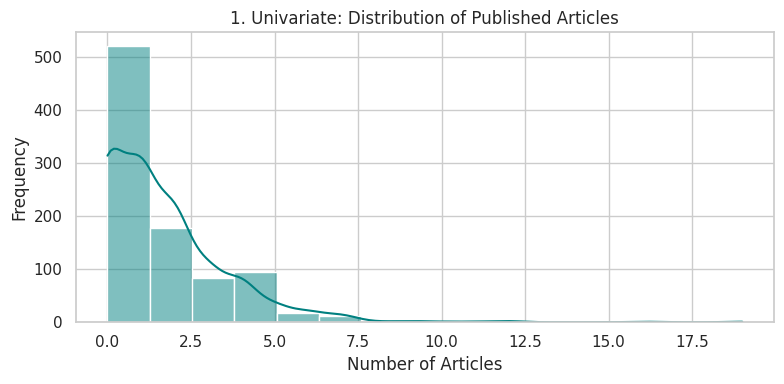

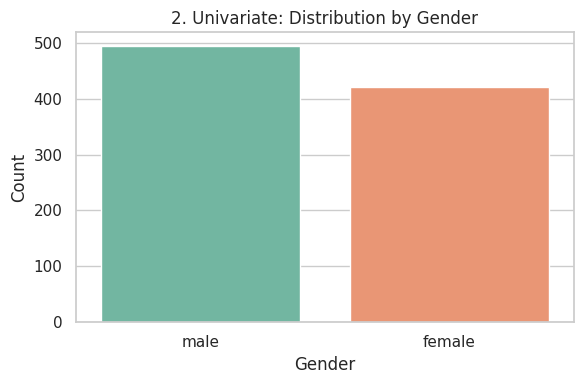

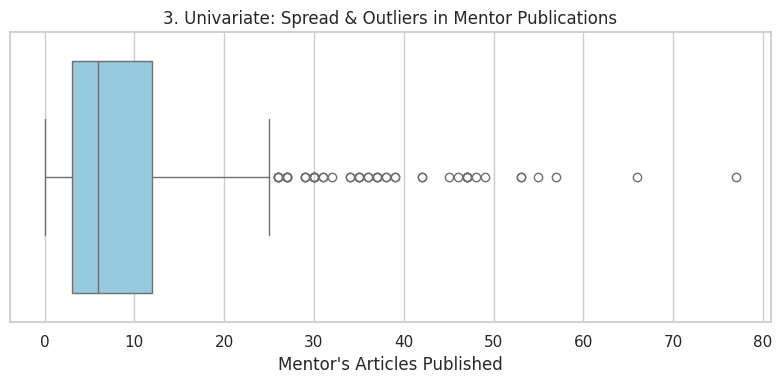

In [20]:
# TASK 6: UNIVARIATE ANALYSIS (WARNING-FREE)
print("\n=== TASK 6: UNIVARIATE ANALYSIS ===")

# Vis 1: Distribution of Target Variable (Articles)
plt.figure(figsize=(8, 4))
sns.histplot(df['articles'], kde=True, bins=15, color='teal')
plt.title("1. Univariate: Distribution of Published Articles")
plt.xlabel("Number of Articles")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Vis 2: Countplot of Gender Distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='gender', hue='gender', palette='Set2', legend=False)
plt.title("2. Univariate: Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Vis 3: Boxplot of Mentor Article Output
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['mentor'], color='skyblue')
plt.title("3. Univariate: Spread & Outliers in Mentor Publications")
plt.xlabel("Mentor's Articles Published")
plt.tight_layout()
plt.show()


=== TASK 7: BIVARIATE ANALYSIS ===


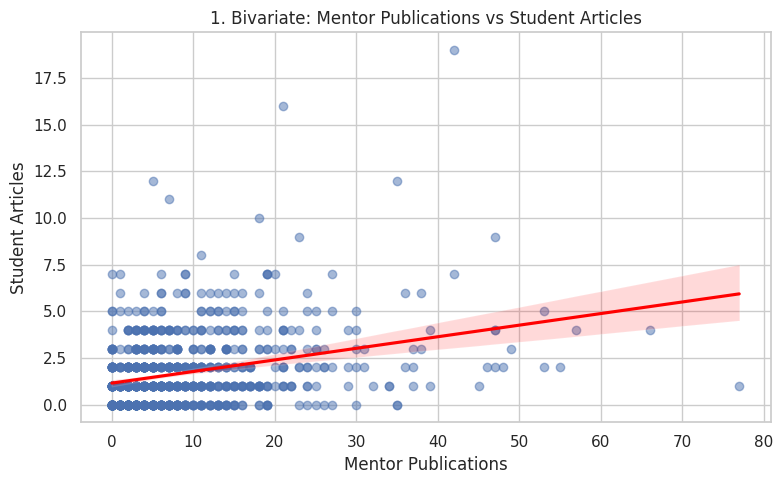

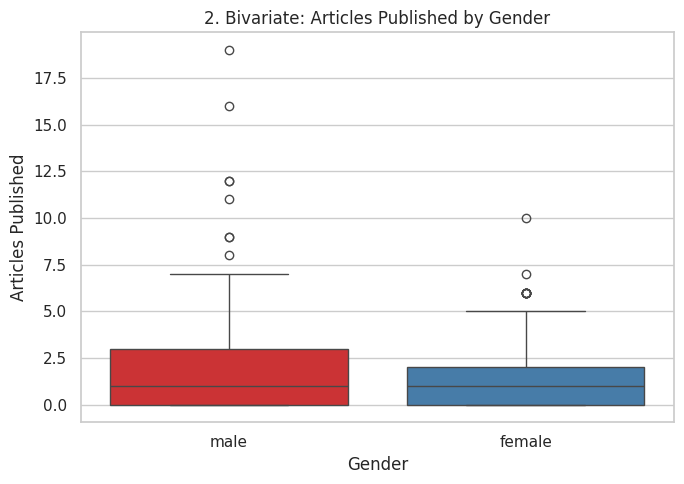

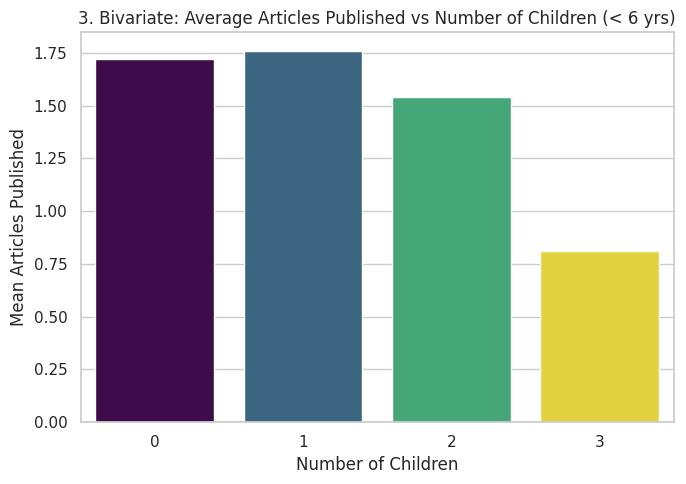

In [19]:
# TASK 7: BIVARIATE ANALYSIS
print("\n=== TASK 7: BIVARIATE ANALYSIS ===")

# Vis 1: Mentor Publications vs Student Articles (Scatter Plot + Regression)
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x='mentor', y='articles', scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})
plt.title("1. Bivariate: Mentor Publications vs Student Articles")
plt.xlabel("Mentor Publications")
plt.ylabel("Student Articles")
plt.tight_layout()
plt.show()

# Vis 2: Student Articles Published by Gender (Box Plot)
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='gender', y='articles', hue='gender', palette='Set1', legend=False)
plt.title("2. Bivariate: Articles Published by Gender")
plt.xlabel("Gender")
plt.ylabel("Articles Published")
plt.tight_layout()
plt.show()

# Vis 3: Average Articles Published by Number of Young Children (Bar Plot)
plt.figure(figsize=(7, 5))
sns.barplot(data=df, x='kids', y='articles', hue='kids', errorbar=None, palette='viridis', legend=False)
plt.title("3. Bivariate: Average Articles Published vs Number of Children (< 6 yrs)")
plt.xlabel("Number of Children")
plt.ylabel("Mean Articles Published")
plt.tight_layout()
plt.show()


=== TASK 8: MULTIVARIATE ANALYSIS ===


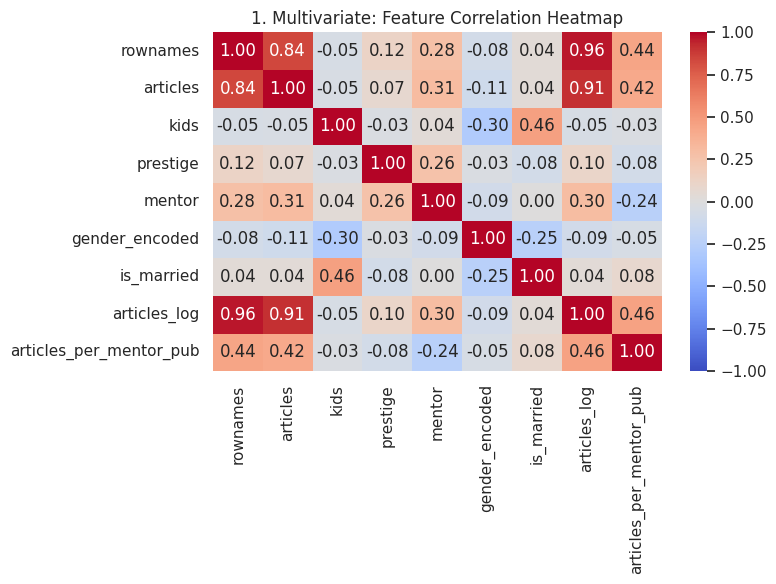

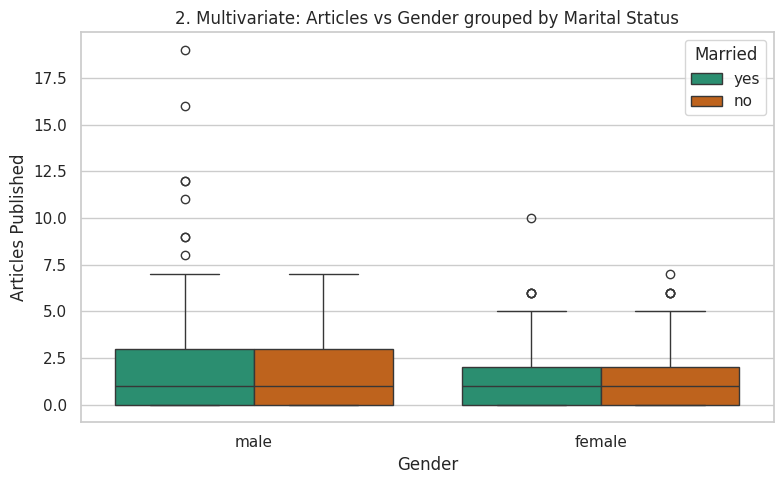

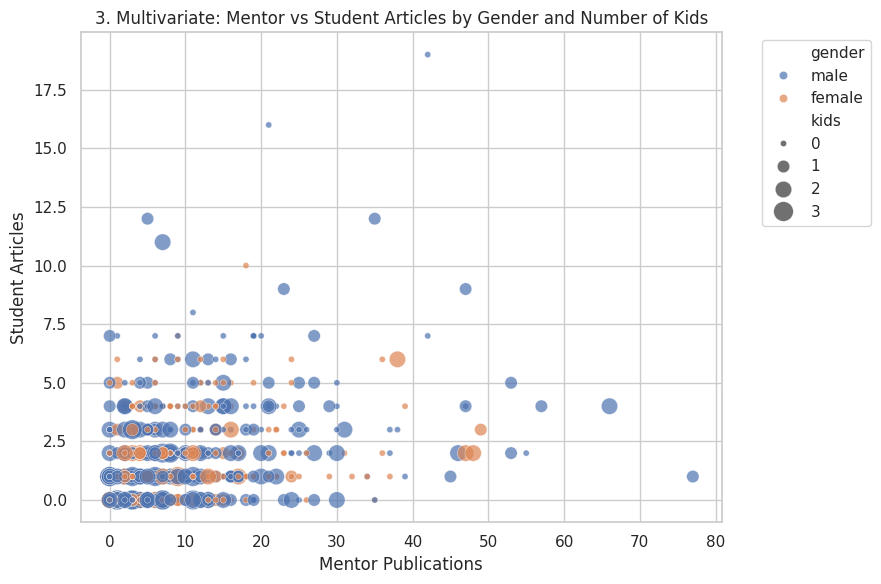


=== PHASE 1 ANALYSIS COMPLETE ===


In [9]:
# TASK 8: MULTIVARIATE ANALYSIS (3 VISUALIZATIONS)
print("\n=== TASK 8: MULTIVARIATE ANALYSIS ===")

# Vis 1: Correlation Matrix Heatmap
plt.figure(figsize=(8, 6))
numeric_df = df_transformed.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title("1. Multivariate: Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

# Vis 2: Articles by Gender and Marital Status (Catplot / Boxplot)
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='gender', y='articles', hue='married', palette='Dark2')
plt.title("2. Multivariate: Articles vs Gender grouped by Marital Status")
plt.xlabel("Gender")
plt.ylabel("Articles Published")
plt.legend(title="Married")
plt.tight_layout()
plt.show()

# Vis 3: Mentor Publications vs Student Articles by Gender & Kids
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x='mentor', y='articles', hue='gender', size='kids', sizes=(20, 200), alpha=0.7)
plt.title("3. Multivariate: Mentor vs Student Articles by Gender and Number of Kids")
plt.xlabel("Mentor Publications")
plt.ylabel("Student Articles")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("\n=== PHASE 1 ANALYSIS COMPLETE ===")